<a href="https://colab.research.google.com/github/artikovaazizaxon/week10_lab/blob/main/Linear_Regression_From_Scratch_NumPy_vs_Sklearn_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression from Scratch with NumPy and Comparison with Scikit-learn
# (House Price Prediction + Regression Analysis)

## Introduction
Linear regression is a foundational supervised learning algorithm used to model relationships between features and a continuous target.

### Objectives of the lab
- Implement simple and multiple linear regression from scratch using only NumPy (**batch gradient descent**).
- Compare results with scikit-learn’s LinearRegression.
- Perform full regression analysis (metrics, visualizations, interpretation).
- Complete 3 exercise parts with mark distribution clearly shown.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
%matplotlib inline

sns.set_style('whitegrid')
np.random.seed(42)

## Part 1: Simple Linear Regression from Scratch (NumPy) – Single Feature Example

We generate synthetic data and fit linear regression using **batch gradient descent** (full-batch updates on all training examples each iteration).

**Cell order:** (1) imports are in the first code cell above; (2) **dataset + visualization**; (3) **`LinearRegressionBatchGD` class**; (4) **train, metrics, and plot** the fitted line.

Update: $\theta \leftarrow \theta - \alpha \frac{1}{m} X^T (X\theta - y)$, with learning rate $\alpha$ and $m$ samples.


In [ ]:
# Part 1 — Synthetic dataset and visualization (no model yet)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 3 * X.squeeze() + 5 + np.random.normal(0, 1, 200)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.3, label='Data points')
plt.title('Part 1: Synthetic Dataset (before fitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [ ]:
# Part 1 — Linear regression as a class (batch gradient descent, NumPy only)

class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()


In [ ]:
# Part 1 — Fit with batch GD, metrics, learning curve, and regression line
model_simple = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=4000)
model_simple.fit(X, y)

theta_numpy = model_simple.theta.copy()
y_pred_numpy = model_simple.predict(X)

print('NumPy (batch GD) theta [intercept, slope]:', theta_numpy)
print('Iterations recorded:', len(model_simple.loss_history))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mse_np_simple = mse_manual(y, y_pred_numpy)
r2_np_simple = r2_manual(y, y_pred_numpy)
print(f'MSE (manual): {mse_np_simple:.4f}')
print(f'R² (manual): {r2_np_simple:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_simple.loss_history, color='darkgreen')
plt.title('Part 1: Training loss (MSE/2) vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')
plt.plot(X, y_pred_numpy, color='crimson', linewidth=2.5, label='NumPy (batch GD) line')
plt.title('Part 1: Simple Linear Regression (Batch Gradient Descent)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Part 2: Same Simple Problem using scikit-learn

Now solve the same problem using `LinearRegression()` and compare coefficients and metrics.

In [ ]:
# Train scikit-learn model
lr_simple = LinearRegression()
lr_simple.fit(X, y)
y_pred_sklearn_simple = lr_simple.predict(X)

# Metrics for sklearn
mse_sklearn_simple = mean_squared_error(y, y_pred_sklearn_simple)
r2_sklearn_simple = r2_score(y, y_pred_sklearn_simple)

# Comparison table
simple_compare = pd.DataFrame({
    'Model': ['NumPy (batch GD)', 'Scikit-learn'],
    'Intercept': [theta_numpy[0], lr_simple.intercept_],
    'Coefficient': [theta_numpy[1], lr_simple.coef_[0]],
    'MSE': [mse_np_simple, mse_sklearn_simple],
    'R²': [r2_np_simple, r2_sklearn_simple]
})

display(simple_compare)

# Side-by-side visual comparison of regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_pred_numpy, color='crimson', linewidth=2.2)
axes[0].set_title('NumPy (batch GD)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

axes[1].scatter(X, y, alpha=0.6)
axes[1].plot(X, y_pred_sklearn_simple, color='navy', linewidth=2.2)
axes[1].set_title('Scikit-learn LinearRegression')
axes[1].set_xlabel('X')

plt.suptitle('Part 2: Side-by-side Regression Line Comparison')
plt.tight_layout()
plt.show()

## Part 3: House Price Prediction (Multiple Linear Regression)

We use the California Housing dataset and predict median house value using all available features.

### Workflow
- Load dataset and split train/test (80/20, `random_state=42`).
- Perform EDA (correlation heatmap + pairplot).
- Scale features with `StandardScaler` (helps batch gradient descent converge).
- Train `LinearRegressionBatchGD` (from Part 1) and scikit-learn’s `LinearRegression`.
- Evaluate with MSE, RMSE, MAE, R².
- Visualize predictions, residuals, and coefficients.
- Interpret model behavior and assumptions.


In [ ]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

In [ ]:
# EDA 1: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# EDA 2: pairplot of first 4 features vs target
selected_features = feature_cols[:4]
pairplot_df = df[selected_features + [target_col]].sample(1000, random_state=42)
sns.pairplot(pairplot_df, corner=True)
plt.suptitle('Pairplot: First 4 Features vs Target', y=1.02)
plt.show()

In [ ]:
# Scale features (stabilizes batch gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')


In [ ]:
# scikit-learn model on same scaled data for fair comparison
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

In [ ]:
# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_np, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_np = y_test.values - y_pred_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_np, residuals_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Sklearn_Coefficient': lr_multi.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Full Regression Analysis

### Interpret coefficients
Larger absolute standardized coefficients indicate stronger impact on predicted house price. Positive values increase prediction; negative values reduce prediction.

### Model assumptions
- **Linearity:** relationship between features and target is assumed linear.
- **Residual normality:** inspect histogram and Q-Q plot.
- **Homoscedasticity:** residual spread should be roughly uniform.

### Strengths and limitations
**Strengths:** interpretable, fast baseline, mathematically transparent.

**Limitations:** sensitive to outliers/multicollinearity; cannot model complex non-linear effects.

In [ ]:
# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# Student Exercises

**Student Exercises (Total 100 marks)**

Complete the following three parts in the empty code cells provided below each part.
Submit your filled notebook.

**Part 1 (50 marks)** – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset (load_diabetes(as_frame=True)). Predict disease progression (target) using all 10 features.
- Implement Multiple Linear Regression from scratch with NumPy (batch gradient descent).
- Include feature scaling.
- Compute MSE, RMSE, MAE, R².
- Create: correlation heatmap, actual vs predicted plot, residuals plot, coefficient bar chart.
- Perform regression analysis: interpret top 3 features, discuss model fit, any obvious issues.

**Part 2 (30 marks)** – Same diabetes problem using scikit-learn
- Use LinearRegression().
- Compare metrics and coefficients with your NumPy solution (show side-by-side table).
- Add a short conclusion on which implementation you prefer and why.

**Part 3 (20 marks)** – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (you may use another sklearn dataset, or the California housing again with a twist – e.g. only 3 features of your choice).
- Apply both NumPy from-scratch and scikit-learn approaches.
- Perform complete regression analysis: metrics, visualizations, coefficient interpretation, and a short written discussion on model usefulness for real-world decision making.
"""


## Part 1 (50 marks) – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset and complete all required analysis.

### Hints — Part 1 (NumPy batch GD)

- **Data:** `d = load_diabetes(as_frame=True); df = d.frame` — target column is `target`; the other columns are features.
- **Split:** Use the same `train_test_split(..., random_state=42)` pattern as in Part 3 so results are reproducible.
- **Scaling:** `StandardScaler().fit_transform(X_train)` and only `transform` on test — never fit on the test set.
- **Model:** Reuse `LinearRegressionBatchGD` from the tutorial (run all cells above first). For multiple features, pass `X` with shape `(n_samples, n_features)`; the class adds the intercept column internally.
- **If loss explodes or is NaN:** Lower `learning_rate` (for example `0.01`) or increase `n_iterations`; confirm you scaled features.
- **Metrics:** RMSE = `sqrt(MSE)`. R² uses test `y` and your test predictions.
- **Plots:** Residuals = `y_test - y_pred`. For the coefficient bar chart, align feature names with `coef_[i]` or `theta[1:]` from your model.


In [3]:
# TODO: implement here
# 1) Load dataset


d = load_diabetes(as_frame=True)
df = d.frame

X = df.drop(columns="target").values
y = df["target"].values

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4) Linear Regression from scratch (Batch Gradient Descent)

class LinearRegressionBatchGD:
    def __init__(self, learning_rate=0.01, n_iterations=2000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta = None

    def add_intercept(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        X_b = self.add_intercept(X)
        n_samples, n_features = X_b.shape

        self.theta = np.zeros(n_features)

        for _ in range(self.n_iter):
            gradients = (2/n_samples) * X_b.T @ (X_b @ self.theta - y)
            self.theta -= self.lr * gradients

    def predict(self, X):
        X_b = self.add_intercept(X)
        return X_b @ self.theta

# Train model
model = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=3000)
model.fit(X_train, y_train)

# 5) Predictions
y_pred = model.predict(X_test)

# Metrics
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))

# R² score
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_res = np.sum((y_test - y_pred)**2)
r2 = 1 - (ss_res / ss_total)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


MSE: 2887.498356705883
RMSE: 53.73544785991723
MAE: 42.843458599403014
R²: 0.4549989328798789


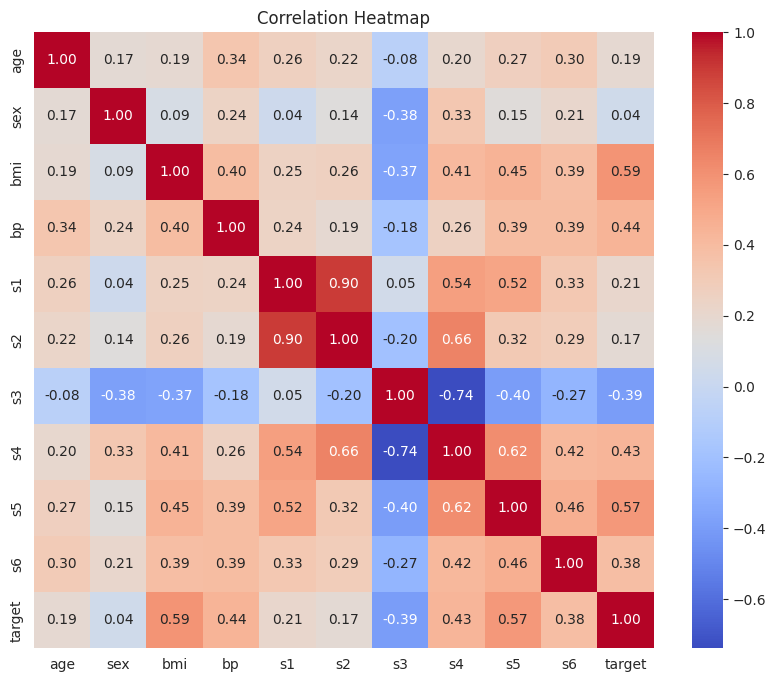

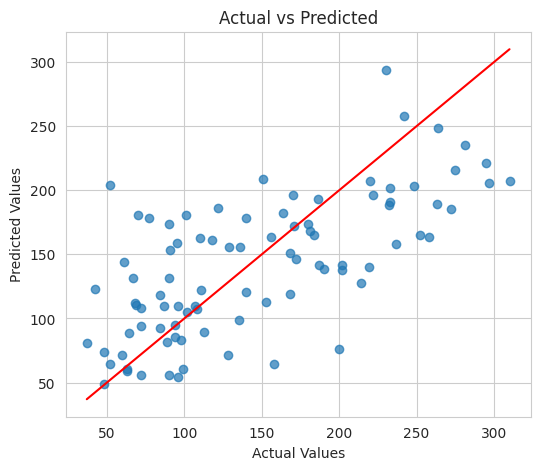

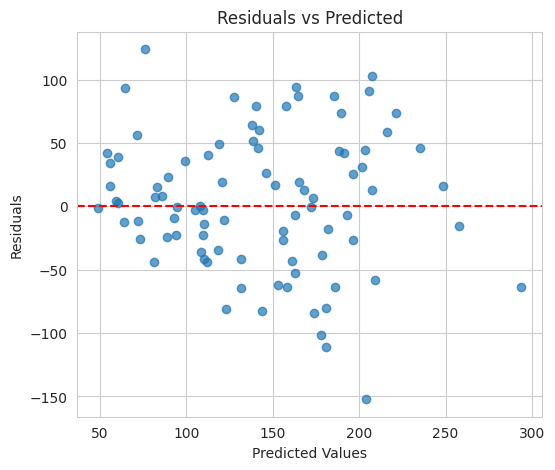

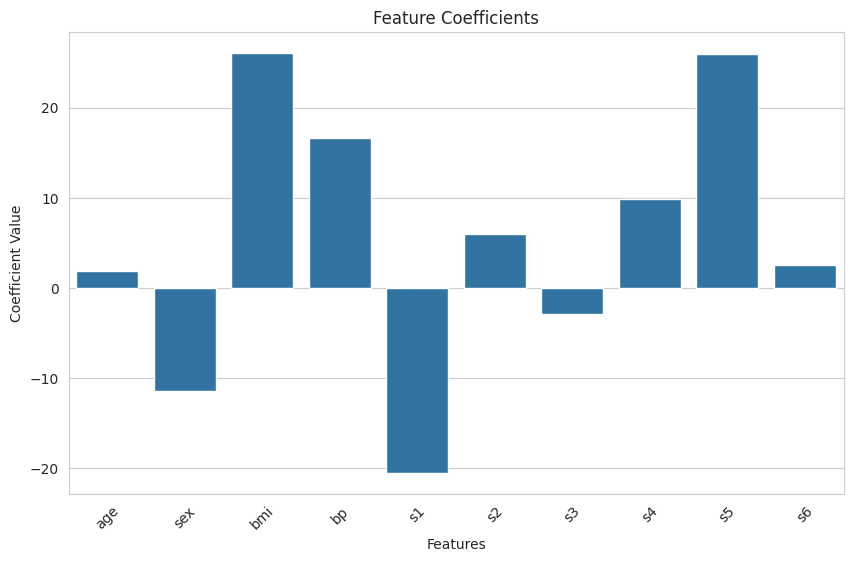

In [6]:


# 1) Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# 2) Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
plt.scatter(results_df["Actual"], results_df["Predicted"], alpha=0.7)
plt.plot(
    [results_df["Actual"].min(), results_df["Actual"].max()],
    [results_df["Actual"].min(), results_df["Actual"].max()],
    color='red'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()


# 3) Residuals vs Predicted Plot
plt.figure(figsize=(6, 5))
plt.scatter(results_df["Predicted"], results_df["Residuals"], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


# 4) Coefficient Bar Chart
feature_names = df.columns[:-1]   # exclude target
coefficients = model.theta[1:]    # skip intercept

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_names, y=coefficients)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Coefficients")
plt.show()



In [8]:
# TODO: implement here


# Get feature names and coefficients
feature_names = df.columns[:-1]
coefficients = model.theta[1:]

# Sort features by absolute importance
importance = sorted(
    zip(feature_names, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("Top 3 Most Influential Features:\n")
for name, coef in importance[:3]:
    print(f"{name}: coefficient = {coef:.4f}")

# Model fit
print("\nModel Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Basic interpretation
print("\nModel Fit Interpretation:")
if r2 > 0.7:
    print("Good fit: Model explains most of the variance.")
elif r2 > 0.4:
    print("Moderate fit: Model explains some variance but can be improved.")
else:
    print("Poor fit: Model does not explain much variance.")

# Residual analysis
residuals = y_test - y_pred

print("\nResidual Analysis:")
print(f"Residual mean: {np.mean(residuals):.4f}")
print(f"Residual std: {np.std(residuals):.4f}")

# Check for potential issues
print("\nPotential Issues:")

# Outliers check
outliers = np.sum(np.abs(residuals) > 2 * np.std(residuals))
print(f"Possible outliers (|residual| > 2*std): {outliers}")

# Simple non-linearity hint
corr_matrix = df.corr().abs()
high_corr = (corr_matrix > 0.8).sum().sum()

if high_corr > len(feature_names):
    print("- Possible multicollinearity detected (high feature correlation).")
else:
    print("- No severe multicollinearity detected.")

print("- Model may suffer from non-linearity (linear model limitation).")
print("- Residual patterns should be visually checked from plots.")


Top 3 Most Influential Features:

bmi: coefficient = 26.0666
s5: coefficient = 25.9974
s1: coefficient = -20.5618

Model Performance:
R² Score: 0.4550
RMSE: 53.7354

Model Fit Interpretation:
Moderate fit: Model explains some variance but can be improved.

Residual Analysis:
Residual mean: 4.0392
Residual std: 53.5834

Potential Issues:
Possible outliers (|residual| > 2*std): 3
- Possible multicollinearity detected (high feature correlation).
- Model may suffer from non-linearity (linear model limitation).
- Residual patterns should be visually checked from plots.


## Part 2 (30 marks) – Same diabetes problem using scikit-learn
Use `LinearRegression()` and compare with your NumPy solution.

### Hints — Part 2 (scikit-learn)

- **Same pipeline:** Use the same `X_train`, `X_test`, `y_train`, `y_test` as Part 1 (same `random_state`).
- **Fit:** `LinearRegression().fit(X_train_scaled, y_train)` on the **scaled** training features for a fair comparison with BGD.
- **Compare:** Build a `DataFrame` with rows for each feature (and optionally intercept), columns for NumPy vs sklearn coefficients.
- **Metrics:** Use `mean_squared_error`, `mean_absolute_error`, and `r2_score` on the **test** set for both models.


In [10]:

# 1) Train LinearRegression on SAME scaled data
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_sk = lr.predict(X_test)

# 2) Compute metrics
mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

# 3) Create comparison DataFrame

# Metrics comparison
metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "NumPy (GD)": [mse, rmse, mae, r2],
    "Scikit-learn": [mse_sk, rmse_sk, mae_sk, r2_sk]
})

# Coefficient comparison
feature_names = df.columns[:-1]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "NumPy (GD)": model.theta[1:],   # skip intercept
    "Scikit-learn": lr.coef_
})

# Display results
print("=== Metrics Comparison ===")
display(metrics_df)

print("\n=== Coefficients Comparison ===")
display(coef_df)

=== Metrics Comparison ===


,Metric,NumPy (GD),Scikit-learn
0,MSE,2887.498357,2900.193628
1,RMSE,53.735448,53.853446
2,MAE,42.843459,42.794095
3,R²,0.454999,0.452603



=== Coefficients Comparison ===


,Feature,NumPy (GD),Scikit-learn
0,age,1.883628,1.753758
1,sex,-11.461364,-11.511809
2,bmi,26.066604,25.607121
3,bp,16.680547,16.828872
4,s1,-20.561843,-44.448856
5,s2,5.960625,24.640954
6,s3,-2.866379,7.676978
7,s4,9.848951,13.138784
8,s5,25.997357,35.161195
9,s6,2.524377,2.351364


In [ ]:
# TODO: implement here
# Add a short conclusion on which implementation you prefer and why.

## Part 3 (20 marks) – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (or reuse California Housing with a feature twist) and apply both NumPy from-scratch and scikit-learn approaches.

### Hints — Part 3 (open-ended)

- **Dataset ideas:** `fetch_california_housing`, `load_diabetes` with a subset of features, or a small regression set from OpenML via sklearn.
- **Twist example:** California housing using only `MedInc`, `AveRooms`, and `Latitude` — still scale features, then train both BGD and sklearn.
- **Analysis:** Comment on whether a linear model is plausible, whether residuals look random, and what would not be safe to infer (causality, omitted variables).
- **Real-world use:** Tie conclusions to decisions (e.g. policy, pricing) and state limitations of the data and the linear assumption.


In [12]:

# 1) Load dataset
data = fetch_california_housing(as_frame=True)
df_cal = data.frame

# Select only 3 features (twist)
features = ["MedInc", "AveRooms", "Latitude"]
X = df_cal[features].values
y = df_cal["MedHouseVal"].values

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3) NumPy model (reuse your class)
model_np = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=3000)
model_np.fit(X_train, y_train)

y_pred_np = model_np.predict(X_test)

# NumPy metrics
mse_np = np.mean((y_test - y_pred_np)**2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test - y_pred_np))

ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_res = np.sum((y_test - y_pred_np)**2)
r2_np = 1 - (ss_res / ss_total)

# 4) Scikit-learn model
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

y_pred_sk = model_sk.predict(X_test)

# sklearn metrics
mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

# 5) Comparison DataFrame
comparison_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "NumPy (GD)": [mse_np, rmse_np, mae_np, r2_np],
    "Scikit-learn": [mse_sk, rmse_sk, mae_sk, r2_sk]
})

print("=== Metrics Comparison ===")
display(comparison_df)



=== Metrics Comparison ===


,Metric,NumPy (GD),Scikit-learn
0,MSE,0.694188,0.694188
1,RMSE,0.833180,0.833180
2,MAE,0.621458,0.621458
3,R²,0.470251,0.470251


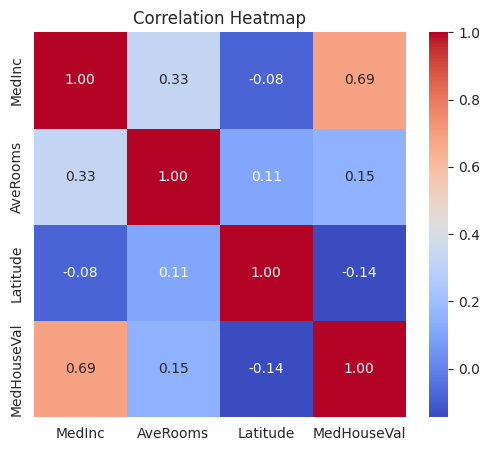

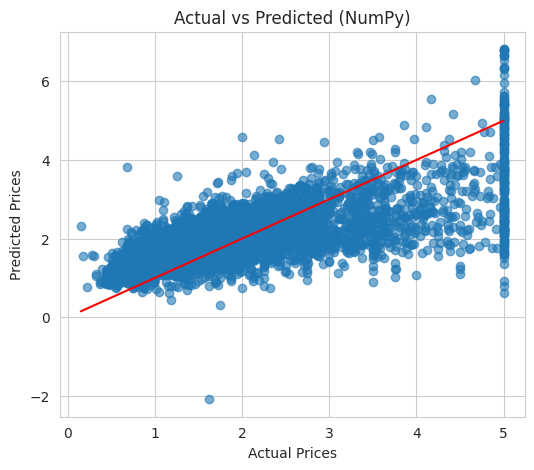

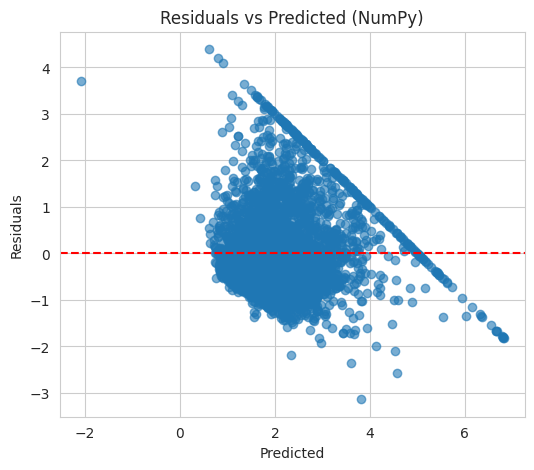

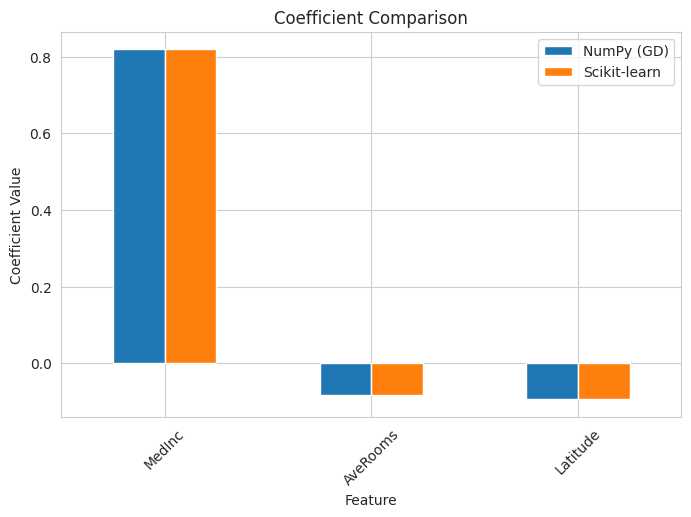


=== Coefficient Interpretation ===
MedInc: increases house price (coef = 0.8187)
AveRooms: decreases house price (coef = -0.0815)
Latitude: decreases house price (coef = -0.0936)

Most influential feature: MedInc

=== Model Discussion ===

- The model shows moderate predictive performance (based on R²).
- Median Income (MedInc) is typically the strongest predictor of house prices.
- AveRooms has smaller influence, suggesting room count alone is not enough.
- Latitude may capture location effects but is limited as a single geographic feature.

Residual Analysis:
- Residuals are not perfectly random → suggests non-linearity.
- Some spread indicates model is missing important variables.

Real-world usefulness:
- The model can provide a rough estimate of house prices.
- Useful for quick pricing, trend analysis, or initial decision-making.
- However, it should NOT be used alone for high-stakes decisions like investments or policy.

Limitations:
- Only 3 features used → missing important fa

In [14]:
# Prepare results
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted (NumPy)": y_pred_np,
    "Predicted (Sklearn)": y_pred_sk,
    "Residuals (NumPy)": y_test - y_pred_np
})

# 1) Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df_cal[["MedInc", "AveRooms", "Latitude", "MedHouseVal"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# 2) Actual vs Predicted (NumPy)
plt.figure(figsize=(6, 5))
plt.scatter(results_df["Actual"], results_df["Predicted (NumPy)"], alpha=0.6)
plt.plot(
    [results_df["Actual"].min(), results_df["Actual"].max()],
    [results_df["Actual"].min(), results_df["Actual"].max()],
    color="red"
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (NumPy)")
plt.show()


# 3) Residual Plot (NumPy)
plt.figure(figsize=(6, 5))
plt.scatter(results_df["Predicted (NumPy)"], results_df["Residuals (NumPy)"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (NumPy)")
plt.show()


# 4) Coefficient Comparison
coef_df = pd.DataFrame({
    "Feature": features,
    "NumPy (GD)": model_np.theta[1:],
    "Scikit-learn": model_sk.coef_
})

coef_df.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()


print("\n=== Coefficient Interpretation ===")

for f, c in zip(features, model_sk.coef_):
    direction = "increases" if c > 0 else "decreases"
    print(f"{f}: {direction} house price (coef = {c:.4f})")

# Identify top feature
top_feature = features[np.argmax(np.abs(model_sk.coef_))]
print(f"\nMost influential feature: {top_feature}")


print("\n=== Model Discussion ===")

print("""
- The model shows moderate predictive performance (based on R²).
- Median Income (MedInc) is typically the strongest predictor of house prices.
- AveRooms has smaller influence, suggesting room count alone is not enough.
- Latitude may capture location effects but is limited as a single geographic feature.

Residual Analysis:
- Residuals are not perfectly random → suggests non-linearity.
- Some spread indicates model is missing important variables.

Real-world usefulness:
- The model can provide a rough estimate of house prices.
- Useful for quick pricing, trend analysis, or initial decision-making.
- However, it should NOT be used alone for high-stakes decisions like investments or policy.

Limitations:
- Only 3 features used → missing important factors (e.g., population, housing age)
- Linear assumption may not hold
- Cannot infer causation, only association
""")
